Mounted at /content/drive
Dropping remaining non-numeric columns: ['trim', 'body', 'state', 'model_new_x', 'model_new2', 'model_new_y']
Final encoded feature count: 664
Dataset shape: (67097, 664)
Target shape: (67097,)
Number of bins actually used: 33

Train shape: (50322, 664)
Test shape: (16775, 664)

Training model epoch by epoch...
Epoch 01 | Train Loss: 2.1272 | Test Acc: 0.3713 | Test Bin MAE: 1.0692 | Test Price MAE: 2074.24 | Test Price RMSE: 4546.15
Epoch 02 | Train Loss: 1.5197 | Test Acc: 0.4312 | Test Bin MAE: 0.8739 | Test Price MAE: 1664.11 | Test Price RMSE: 3757.74
Epoch 03 | Train Loss: 1.3984 | Test Acc: 0.4634 | Test Bin MAE: 0.7949 | Test Price MAE: 1467.12 | Test Price RMSE: 3178.93
Epoch 04 | Train Loss: 1.3338 | Test Acc: 0.4813 | Test Bin MAE: 0.7567 | Test Price MAE: 1366.47 | Test Price RMSE: 2787.81
Epoch 05 | Train Loss: 1.2910 | Test Acc: 0.4890 | Test Bin MAE: 0.7425 | Test Price MAE: 1305.31 | Test Price RMSE: 2591.70
Epoch 06 | Train Loss: 1.2603 | Test

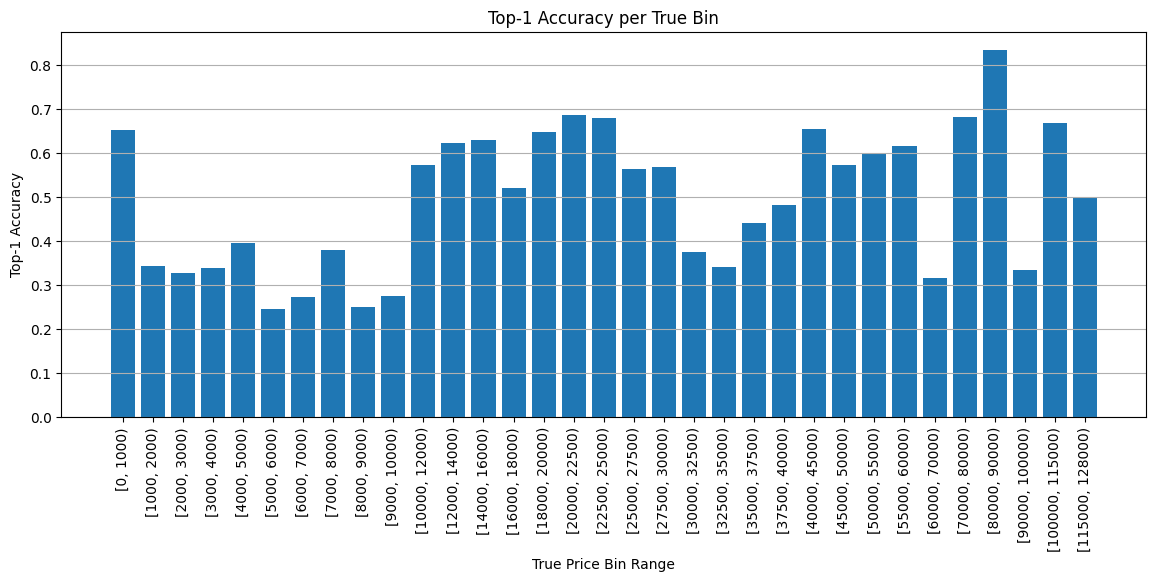

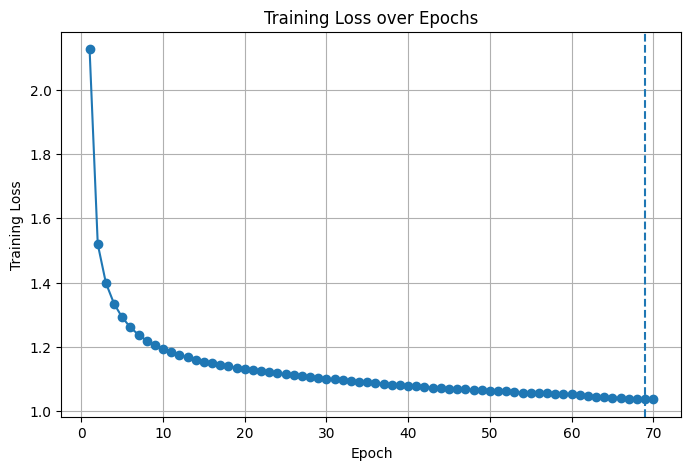

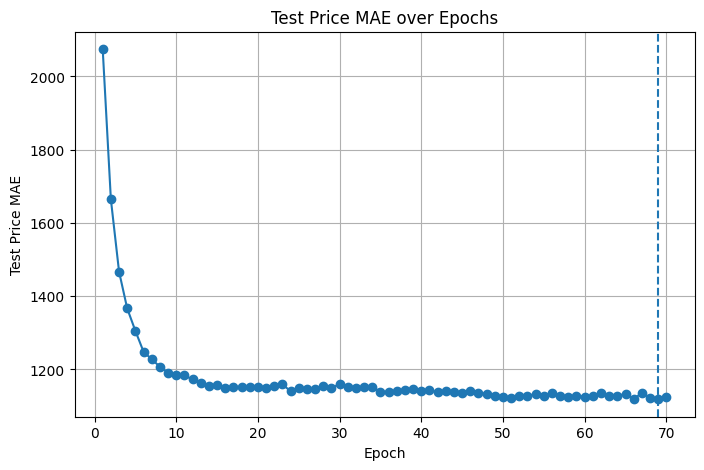

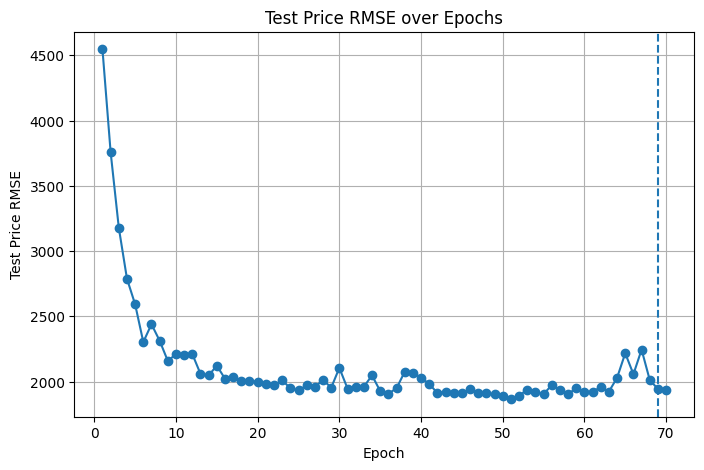

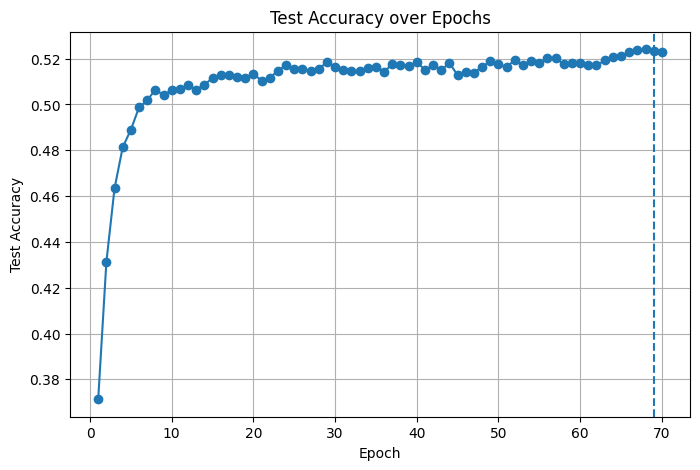

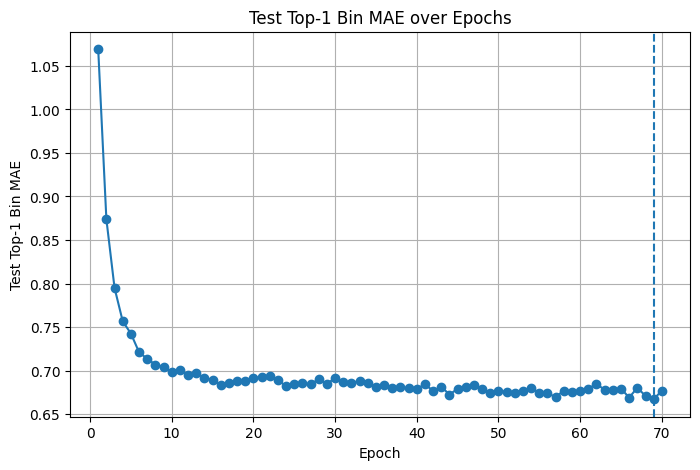

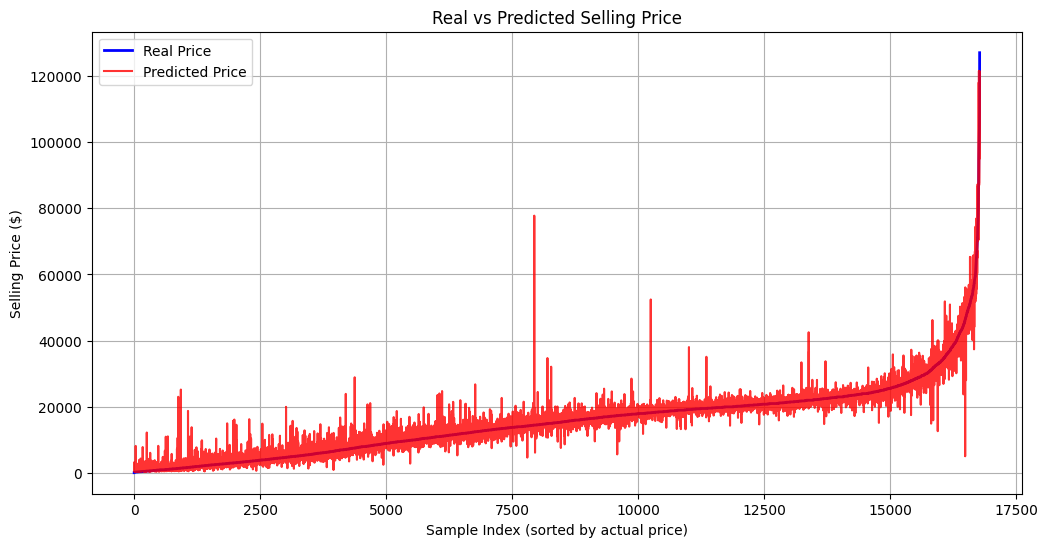

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.exceptions import ConvergenceWarning
import warnings

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# might need to change this
df = pd.read_csv('/content/drive/MyDrive/output2.csv')

# target
df["sellingprice"] = pd.to_numeric(df["sellingprice"], errors="coerce")
df = df.dropna(subset=["sellingprice"])
df = df[(df["sellingprice"] >= 100) & (df["sellingprice"] < 128000)].copy()

bin_edges = np.array([
    0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000,
    12000, 14000, 16000, 18000, 20000,
    22500, 25000, 27500, 30000, 32500, 35000, 37500, 40000,
    45000, 50000, 55000, 60000,
    70000, 80000, 90000, 100000, 115000, 128000
], dtype=float)

num_bins = len(bin_edges) - 1

df["price_bin"] = pd.cut(
    df["sellingprice"],
    bins=bin_edges,
    labels=False,
    include_lowest=True,
    right=False
)

df = df.dropna(subset=["price_bin"]).copy()
df["price_bin"] = df["price_bin"].astype(int)

# remove bins that are too rare
bin_counts = df["price_bin"].value_counts()
valid_bins = bin_counts[bin_counts >= 5].index
df = df[df["price_bin"].isin(valid_bins)].copy()

sellingprice = df["sellingprice"]

drop_cols = [
    "sellingprice", "price_bin",
    "interior", "transmission", "seller", "saledate", "color", "vin"
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
X = X.drop(columns=[c for c in X.columns if "Unnamed:" in c], errors="ignore")

# only encode make, model
one_hot_cols = [c for c in ["make", "model"] if c in X.columns]

for col in one_hot_cols:
    X[col] = X[col].astype(str)

X = pd.get_dummies(X, columns=one_hot_cols, drop_first=False)

# remove any other remaining non-numeric columns
non_numeric_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
if non_numeric_cols:
    print("Dropping remaining non-numeric columns:", non_numeric_cols)
    X = X.drop(columns=non_numeric_cols)

X = X.fillna(0)
X = X.drop(columns=[c for c in X.columns if "Unnamed:" in c], errors="ignore")

y = df["price_bin"]

print("Final encoded feature count:", X.shape[1])
print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
print("Number of bins actually used:", y.nunique())
print()

X = X.astype(np.float32)
y = y.astype(int)

# shuffle
shuffled_idx = np.random.RandomState(42).permutation(len(X))
X = X.iloc[shuffled_idx].reset_index(drop=True)
y = y.iloc[shuffled_idx].reset_index(drop=True)
sellingprice = sellingprice.iloc[shuffled_idx].reset_index(drop=True)

# split 75/25
split_idx = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
price_train, price_test = sellingprice.iloc[:split_idx], sellingprice.iloc[split_idx:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()

# fit scaler once
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# bin midpoints for price prediction
bin_midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2

# manual epoch-by-epoch training
max_epochs = 70
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64, 32, 33),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=256,
    learning_rate="adaptive",
    max_iter=1,
    warm_start=True,
    early_stopping=True,
    random_state=42
)

train_loss_history = []
test_price_mae_history = []
test_price_rmse_history = []
test_top1_bin_mae_history = []
test_accuracy_history = []

best_epoch = None
best_price_mae = np.inf
best_mlp = None

print("Training model epoch by epoch...")

for epoch in range(1, max_epochs + 1):
    mlp.fit(X_train_scaled, y_train)

    # record training loss
    train_loss_history.append(mlp.loss_)

    # predictions on test set
    y_pred = mlp.predict(X_test_scaled)
    y_proba = mlp.predict_proba(X_test_scaled)
    classes = mlp.classes_

    # accuracy and bin MAE
    test_acc = accuracy_score(y_test, y_pred)
    test_bin_mae = mean_absolute_error(y_test, y_pred)

    # map probabilities into full bin space
    prob_matrix = np.zeros((len(y_proba), num_bins))
    for i, c in enumerate(classes):
        prob_matrix[:, c] = y_proba[:, i]

    predicted_price_avg = prob_matrix @ bin_midpoints
    price_true = price_test.to_numpy()

    test_price_mae = mean_absolute_error(price_true, predicted_price_avg)
    test_price_rmse = np.sqrt(mean_squared_error(price_true, predicted_price_avg))

    # save histories
    test_accuracy_history.append(test_acc)
    test_top1_bin_mae_history.append(test_bin_mae)
    test_price_mae_history.append(test_price_mae)
    test_price_rmse_history.append(test_price_rmse)

    # keep best model by test price MAE
    if test_price_mae < best_price_mae:
        best_price_mae = test_price_mae
        best_epoch = epoch
        best_mlp = copy.deepcopy(mlp)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {mlp.loss_:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"Test Bin MAE: {test_bin_mae:.4f} | "
        f"Test Price MAE: {test_price_mae:.2f} | "
        f"Test Price RMSE: {test_price_rmse:.2f}"
    )

print()
print(f"Best epoch: {best_epoch}")
print(f"Best test price MAE: {best_price_mae:.2f}")
print()

# ---------------------------------------
# Evaluate the best model
# ---------------------------------------
y_pred = best_mlp.predict(X_test_scaled)
y_proba = best_mlp.predict_proba(X_test_scaled)
classes = best_mlp.classes_

acc = accuracy_score(y_test, y_pred)
mae_top1 = mean_absolute_error(y_test, y_pred)

top3_idx = np.argsort(y_proba, axis=1)[:, -3:]
top3_labels = classes[top3_idx]

y_test_array = y_test.to_numpy()

top3_correct = [
    true_val in preds
    for true_val, preds in zip(y_test_array, top3_labels)
]
top3_acc = np.mean(top3_correct)

closest_top3_preds = np.array([
    preds[np.argmin(np.abs(preds - true_val))]
    for preds, true_val in zip(top3_labels, y_test_array)
])
mae_top3 = mean_absolute_error(y_test_array, closest_top3_preds)

prob_matrix = np.zeros((len(y_proba), num_bins))
for i, c in enumerate(classes):
    prob_matrix[:, c] = y_proba[:, i]

predicted_price_avg = prob_matrix @ bin_midpoints

price_true = price_test.to_numpy()

price_mae = mean_absolute_error(price_true, predicted_price_avg)
price_rmse = np.sqrt(mean_squared_error(price_true, predicted_price_avg))

nonzero_mask = price_true != 0
price_mape = np.mean(
    np.abs((predicted_price_avg[nonzero_mask] - price_true[nonzero_mask]) / price_true[nonzero_mask])
) * 100

predicted_price_top1 = bin_midpoints[y_pred]
price_mae_top1 = mean_absolute_error(price_true, predicted_price_top1)
price_rmse_top1 = np.sqrt(mean_squared_error(price_true, predicted_price_top1))

print("Best-model test accuracy:", acc)
print("Best-model test top-3 accuracy:", top3_acc)
print()

print("Best-model test top-1 MAE (bin):", mae_top1)
print("Best-model test top-3 MAE (bin):", mae_top3)
print()

print("Best-model average predicted price MAE:", price_mae)
print("Best-model average predicted price RMSE:", price_rmse)
print("Best-model average predicted price MAPE (%):", price_mape)
print()

print("Best-model top-1 midpoint price MAE:", price_mae_top1)
print("Best-model top-1 midpoint price RMSE:", price_rmse_top1)
print()

results_df = pd.DataFrame({
    "true_bin": y_test_array,
    "pred_top1_bin": y_pred,
    "true_sellingprice": price_true,
    "predicted_price_top1": predicted_price_top1,
    "predicted_price_avg": predicted_price_avg,
    "abs_error_top1_price": np.abs(predicted_price_top1 - price_true),
    "abs_error_avg_price": np.abs(predicted_price_avg - price_true)
})

print(results_df.head())

# ---------------------------------------
# Top-1 accuracy per true bin
# ---------------------------------------
bin_top1_rows = []

for b in sorted(np.unique(y_test_array)):
    mask = (y_test_array == b)
    total_in_bin = np.sum(mask)
    correct_in_bin = np.sum(y_pred[mask] == y_test_array[mask])
    bin_top1_acc = correct_in_bin / total_in_bin if total_in_bin > 0 else np.nan

    bin_top1_rows.append({
        "bin": b,
        "bin_range": f"[{bin_edges[b]:.0f}, {bin_edges[b+1]:.0f})",
        "test_count": total_in_bin,
        "correct_count": correct_in_bin,
        "top1_bin_accuracy": bin_top1_acc
    })

bin_top1_df = pd.DataFrame(bin_top1_rows)

print("Top-1 accuracy per true bin:")
print(bin_top1_df)
print()

plt.figure(figsize=(14, 5))
plt.bar(bin_top1_df["bin_range"], bin_top1_df["top1_bin_accuracy"])
plt.xlabel("True Price Bin Range")
plt.ylabel("Top-1 Accuracy")
plt.title("Top-1 Accuracy per True Bin")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

# ---------------------------------------
# plots
# ---------------------------------------
epochs = np.arange(1, max_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_history, marker="o")
plt.axvline(best_epoch, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, test_price_mae_history, marker="o")
plt.axvline(best_epoch, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Test Price MAE")
plt.title("Test Price MAE over Epochs")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, test_price_rmse_history, marker="o")
plt.axvline(best_epoch, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Test Price RMSE")
plt.title("Test Price RMSE over Epochs")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, test_accuracy_history, marker="o")
plt.axvline(best_epoch, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy over Epochs")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, test_top1_bin_mae_history, marker="o")
plt.axvline(best_epoch, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Test Top-1 Bin MAE")
plt.title("Test Top-1 Bin MAE over Epochs")
plt.grid(True)
plt.show()

# ---------------------------------------
# plot real price and predicted price
# sorted by actual price
# ---------------------------------------
sorted_idx = np.argsort(price_true)

price_true_sorted = price_true[sorted_idx]
predicted_price_sorted = predicted_price_avg[sorted_idx]

plt.figure(figsize=(12, 6))
plt.plot(price_true_sorted, color="blue", linewidth=2, label="Real Price")
plt.plot(predicted_price_sorted, color="red", linewidth=1.5, alpha=0.8, label="Predicted Price")

plt.xlabel("Sample Index (sorted by actual price)")
plt.ylabel("Selling Price ($)")
plt.title("Real vs Predicted Selling Price")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!pip install joblib
import joblib
joblib.dump(best_mlp, "model")

['model']